In [58]:
%matplotlib inline

## Aprendizaje Profundo para el Análisis de Imágenes
## Grados en Ingeniería de Telecomunicación

# PROYECTO 2A:
# SEGMENTACIÓN DE IMÁGENES CON DEEPLAB-V3

<center><img src='https://www.uc3m.es/ss/Satellite?blobcol=urldata&blobkey=id&blobtable=MungoBlobs&blobwhere=1371614316787&ssbinary=true' width=400 /></center>

El propósito de este proyecto es que el estudiantado se familiarice con una red neuronal convolucional (CNN) para segmentación semántica de imágenes (en la que a cada píxel de la imagen de entrada se asocia una clase de objeto). En concreto, en este tutorial se realizará _fine-tuning_ sobre la red `Deeplab-V3`. El objetivo del proyecto es que el estudiantado analice los bloques específicos para segmentación de la arquitectura de red y trabaje sobre otros conceptos como el _data augmentation_ o la función de coste de la red neuronal en un escenario real con el objetivo de mejorar el aprendizaje de la misma.

En concreto, se realizará _fine-tuning_ sobre la red `Deeplab-V3`, una de las redes del estado del arte para segmentación semántica. En nuestro caso, la primera tarea de segmentación a la que se va a aplicar esta arquitectura es la segmentación de objetos en imágenes convencionales, utilizando un subconjunto de la base de datos PascalVOC2012.

Este tutorial es una adaptación del tutorial disponible en https://expoundai.wordpress.com/2019/08/30/transfer-learning-for-segmentation-using-deeplabv3-in-pytorch/.

Referencias:
- [1] Deeplab-V3. https://arxiv.org/abs/1706.05587
- [2] Imagen. https://raw.githubusercontent.com/abreheret/PixelAnnotationTool/master/images_test/Abbey_Road.jpg
- [3] Imagen. https://raw.githubusercontent.com/abreheret/PixelAnnotationTool/master/images_test/Abbey_Road_color_mask.png
- [4] Deeplab. https://arxiv.org/abs/1606.00915
- [5] PASCAL VOC 2012 dataset. http://host.robots.ox.ac.uk/pascal/VOC/voc2012/index.html
- [6] Regularización local. http://www.sfu.ca/~abentaie/papers/miccai16.pdf
- [7] Focal Loss for Object Detection. https://arxiv.org/abs/1708.
- [8] Dice Loss. https://arxiv.org/abs/1606.04797

## Antes de empezar

Antes de empezar, en caso de que vaya a utilizar Google Colab, necesita descomprimir los archivos de la práctica en una carpeta en Drive y cambiar el directorio de trabajo al de dicha carpeta. Para ello, ejecute el siguiente código:

In [59]:
# Descomenta únicamente si quieres ejecutar este código en Google Colab
# from google.colab import drive
# import os, sys
# drive.mount('/content/drive')
# print(os.getcwd())
# os.chdir('/content/drive/My Drive/Colab Notebooks/segmentation_folder') #Here put the full path to the folder where you have the files

Además, si quiere ejecutar el código con soporte a GPU, en Google Colab vaya a `Entorno de ejecución->Cambiar tipo entorno de ejecución` y seleccione GPU en `acelerador por hardware`.

## Parte 1. Fundamento teórico

### Segmentación de objetos

Frente a los métodos tradicionales de segmentación de imágenes (*thresholding, clustering* o *region growing*), las técnicas de *deep learning* han demostrado ser mucho más eficaces para tareas complejas de segmentación de imágenes. Sin embargo, estas técnicas requieren grandes bases de datos anotadas píxel a píxel para su entrenamiento, lo que supone un gran esfuerzo de anotación.

El objetivo de un algoritmo de segmentación de objetos es generar máscaras de salida a nivel de píxel en las cuales a las regiones que pertenecen a ciertas categorías se les asigna el mismo valor de píxel. Si se codifican en color (asignando un color diferente a cada clase de objetos) se obtienen resultados como los que se muestran en la siguiente figura [2-3], donde en azul se representa la clase vehículo, en rojo la clase persona, etc.

<table><tr><td><img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/beatles.jpg"></td><td><img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/beatles_mask.png"></td></tr></table>

Por tanto, como entrada a nuestro algoritmo de segmentación se tendrá un conjunto de imágenes y sus correspondientes máscaras *ground truth* píxel a píxel.

### Contexto vs resolución

El principal reto en segmentación semántica es encontrar un compromiso entre la importancia del contexto global de la imagen (para segmentar un objeto, es necesario identificar sus distintas partes y diferenciarlo del resto de objetos de la imagen), y las características locales de la imagen (una segmentación precisa ha de analizar los valores de los píxeles que se encuentran en los alrededores del objeto para delimitar la frontera del mismo). La siguiente figura muestra las distintas estrategias que se utilizan para intentar representar este compromiso sobre CNNs.

<img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/arquitecturas.png">

La aproximación tradicional que se ha seguido para utilizar extraer características de alto nivel de la imagen ha sido el análisis de la misma a través de una representación en pirámide, en la que se consideran la imagen original y versiones de menor tamaño de la misma (filtrado gaussiano y reducción del tamaño mediante submuestreo). Si se aplica el mismo procesado a todos los niveles de la pirámide, se obtienen características de bajo nivel en los primeros niveles, y de alto nivel conforme se va profundizando en la misma (véase la figura a) arriba, donde se puede ver que se mezclan las características de dos pirámides de imagen que parten de distintas escalas). De esta manera, en las versiones de menor tamaño pierde importancia la información local de la imagen en favor de la información global, y viceversa. Las arquitecturas de redes neuronales convolucionales (FCNs) de clasificación se basan en esta representación para intentar resumir la información de la imagen (las características a niveles menos profundos sirven para calcular características a niveles más profundos) y proporcionar su categoría.

Por el contrario, en segmentación no solo importa el contexto global de la imagen, sino que las características locales también cuentan. Las redes totalmente convolucionales para segmentación (*Fully Convolutional Networks*, FCNs) introducen una estructura *encoder-decoder* en la red para obtener una salida con una resolución igual (o lo más cercana posible) a la de la entrada (véase la figura b) arriba). Para ello, el *encoder* reduce paulatinamente la dimensión de los mapas de características de manera que la información global se captura en las capas profundas; y el *decoder* parte de esta información global y paulatinamente recupera la dimensión original de la imagen. Frecuentemente se incluyen conexiones entre las capas de igual dimensión del *encoder* y el *decoder* para facilitar el empleo directo de las características más locales en la salida final de la segmentación.

En las redes Deeplab [1]-[4] se hace uso de las dos estrategias de la derecha: convoluciones *atrous* y *Spatial Pyramid Pooling*. Estas estrategias se explican en la siguiente sección.


### Deeplab-V3

Aunque se recomienda echar un vistazo al artículo sobre Deeplab-V3 [1], en esta sección se van a explicar los conceptos más importantes de la red que son necesarios para el desarrollo de la práctica.

Deeplab-V3 es un _framework_ que adapta cualquier red convolucional dedicada a la clasificación (dada una imagen, encontrar una categoría que describa el contenido total de la imagen) a la segmentación de objetos. Para ello, a partir de un _backbone_ inicial (las capas destinadas a la extracción de características) de cualquier red de clasificación, propone una serie de capas y bloques destinados a extraer características de contexto en la imagen sin comprometer la resolución de los mapas de características (sin reducir aun más su resolución). Para ello, hace uso de las dos estrategias que se describen a continuación.

#### Convoluciones *atrous*

La contribución principal de la familia de redes Deeplab [4] es el diseño de las convoluciones *atrous* o convoluciones *dilated*. Este tipo de convoluciones se utilizan para reemplazar la estrategia tradicional de reducir el tamaño de la imagen a través de capas de *max pooling* con *stride* a lo largo de la red para obtener representaciones más globales del contenido de la imagen. Esta estrategia estándar hace que el *stride* acumulado a lo largo de la red sea muy elevado (32, por ejemplo, lo que significa que el tamaño de las características de una imagen original de $HxW$ es $H/32xW/32$), lo que puede ser contraproducente en segmentación (a pesar de obtener mejores características de contexto, la reducción de las dimensiones de la imagen hace que las segmentaciones sean menos precisas). Las convoluciones *atrous*, por su parte, mantienen la resolución de la entrada a la vez que extraen características de mayor orden a través del uso del *stride*. Es decir, para computar el valor de un cierto píxel $y[i]$ se toman los valores de los píxeles alejados del mismo $r$ posiciones en la entrada $x$ multiplicados por el elemento correspondiente del filtro $w$.

\begin{equation}y[i]=\sum_{k}{x[i+r\cdot k] w[k]}.\end{equation}

En modo filtro, una convolución *atrous* con tasa $r$ se consigue añadiendo $r-1$ ceros entre los elementos del filtro original, como se muestra en la siguiente figura [1]:

<img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/atrous.png" width="600pix">

A continuación se puede observar una animación en la que se comparan una convolución 2D tradicional con una convolución *atrous*, ambas con el mismo *field of view*, pero la primera usa 15 parámetros y la segunda 9 parámetros. Mientras que la convolución estándar usa un filtro de $5x5$, *stride* de 1, *dilate* de 1 y *padding* de 1; la convolución *atrous* usa un filtro de $3x3$, *stride* $r=2$, *dilate* de 2 y no usa *padding*.

<table><tr><td><img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/2dconv.gif"></td><td><img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/atrousconv.gif"></td></tr></table>

En la práctica, estas convoluciones no se utilizan a lo largo de toda la red: en primer lugar, porque reducir el tamaño de la imagen en las primeras capas de la red es útil desde el punto de vista del coste computacional (sería muy costoso trabajar con las imágenes a tamaño completo durante todo el procesado); y en segundo lugar, porque de hecho esta sustitución del *max pooling* por convoluciones *atrous* es más útil en capas profundas de la red (con menos tasa $r$ se recorren grandes porciones de imagen). Un ejemplo de flujo de trabajo sobre ResNet se muestra a continuación [1]:

<img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/atrous2.png">

Se puede ver como a partir del bloque 3 se utilizan convoluciones *atrous* __en cascada__ con tasa variable $2^n$ para sustituir al *max pooling* con tasa 2. De este modo se mantiene la resolución en valores aceptables.

#### *Atrous Spatial Pyramid Pooling*

La segunda contribución del artículo [1] tiene que ver con el uso de las convoluciones *atrous* como extractores de características __en paralelo__ con distinta tasa $r$, de manera que las características que se extraen en cada rama sean más globales o locales en función de dicha tasa. Esto es lo que se llama ASPP (*Atrous Spatial Pyramid Pooling*). Las características de cada rama se pueden agrupar bien mediante suma o bien mediante concatenación, para obtener después la salida final de segmentación de la red.

En concreto, la estructura del *frawework* Deeplab-V3 es la que se muestra a continuación:

<img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/aspp.png">

Se puede observar que se parte de un mapa de características de la imagen con *stride* 16 al que se añade una capa con convoluciones *atrous* con tasa $r=2$ y posteriormente el bloque ASPP. Este consta de los siguientes módulos:

- Una capa con una convolución 1x1 que extrae características más locales del mapa de entrada.
- Sendas convoluciones *atrous* con tasas $r=6$, $r=12$ y $r=18$, respectivamente, que extraen características con diferente contexto global de los mapas de entrada.
- Un *avg pooling* a nivel de mapa de entrada que genera como salida la media de cada canal. Esta característica global de la imagen permite ponderar la importancia de los distintos canales.

### Medidas de evaluación

Para evaluar la calidad en la segmentación de objetos, se suele utilizar la medida *Intersection over Union*, IoU, también denominada *Jaccard Index* (JI). La medida $IoU$ mide la similitud entre dos regiones $A$ y $B$ como:

\begin{equation}
IoU=\frac{A \cap B}{A \cup B}
\end{equation}

siendo $\cap$ la intersección entre las regiones (area común) y $\cup$ la unión o área total que cubren entre ambas. Se considera un umbral mínimo de IoU en torno a $IoU_{th}=0.7$ para considerar una detección como correcta. A continuación se puede ver un ejemplo de la medida $IoU$.

<img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/iou.png">


### Base de datos

La base de datos sobre la que se trabajará en la práctica es un subconjunto de la base de datos PASCAL VOC 2012 [5]. Esta base de datos contiene imágenes con diversos objetos pertenecientes a 20 categorías:
- __Person__: _person_
- __Animal__: _bird, cat, cow, dog, horse, sheep_
- __Vehicle__: _aeroplane, bicycle, boat, bus, car, motorbike, train_
- __Indoor__: _bottle, chair, dining table, potted plant, sofa, tv/monitor_

Las imágenes se proporcionan en sendas carpetas para entrenamiento y test. Los conjuntos se distribuyen de la siguiente manera:
- Entrenamiento: 234 imágenes.
- Test: 68 imágenes.

## Parte 2. Implementación

En primer lugar, se importan las librerías necesarias y se definen algunos parámetros generales.

In [60]:
import os
import glob
from tqdm import tqdm
import numpy as np
import copy
import time
import torch
import torch.nn.functional as FT
from torch.utils.data import Dataset, DataLoader
from torchvision.models.segmentation.deeplabv3 import DeepLabHead
from torchvision.models.segmentation import deeplabv3_resnet101
from torchvision import transforms, utils
import torchvision.transforms.functional as F
from PIL import Image, ImageFile, ImageDraw
import cv2
import csv
import random
import matplotlib.pyplot as plt
# Set random seed for reproducibility
manualSeed = 999
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)
# torch uses some non-deterministic algorithms
torch.backends.cudnn.enabled = False

Random Seed:  999


### Entradas

Se definen algunas entradas para la ejecución:

-  **data_dir** - el directorio raíz de la base de datos, que se describe posteriormente.
-  **num_workers** - el número de hebras para cargar los datos con la clase DataLoader.
-  **img_size** - el tamaño de las imágenes de entrada a la red (cuadradas).
-  **batchsize_train** - el tamaño de _batch_ que se utiliza para entrenamiento.
-  **batchsize_test** - el tamaño de _batch_ que se utiliza para test.
-  **num_classes** - el número de clases que detectar.
-  **class_names** - los nombres de las clases que detectar.
-  **num_epochs** - número de _epochs_ para el entrenamiento de la red.
-  **step_size** - número de *epochs* tras los cuales se reduce el *learning rate* en un factor 0.1.
-  **lr** - *learning rate* inicial.
-  **result_dir** - el directorio raíz para almacenar los resultados.
-  **device** - el dispositivo (GPU o CPU) para la ejecución.

In [61]:
data_dir = "myVOC4"
num_workers=8         # to debug, fix num_workers=0
img_size=512           # Size of the images
batchsize_train=1      # Batch size for training
batchsize_test=1       # Batch size for test (it must be one to generate predictions)
num_classes=5         # Number of classes
class_names = ['background', 'bottle', 'chair', 'diningtable', 'sofa']
num_epochs =8
step_size=5
result_dir = 'results' # Result directory
# Detect if we have a GPU available
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

Device: mps


### Red

La red a utilizar será una versión de Deeplab-V3 con ResNet-101 como *backbone*, ya pre-entrenada sobre el conjunto de entrenamiento de la base de datos COCO. En concreto, se utilizan los 4 primeros bloques de esta red, compuestos de capas convolucionales, normalización de batch (cuyos parámetros se congelan) y capas no lineales. Vea como los bloques se modifican añadiendo convoluciones *atrous* en lugar de *max pooling*, como se ha descrito en el apartado teórico, y a partir del cuarto bloque se añade el bloque de ASPP y la convolución que genera la salida de segmentación.

A continuación se incluye la función que construye la red. Analice la arquitectura.

- ¿Se realiza el submuestreo con capas de *max pooling* en las capas iniciales, y *layers* 1, 2 y 3? ¿Por qué?
- ¿Coinciden las tasas $r$ de las convoluciones *atrous* de los bloques 4 y el ASPP con el apartado teórico? ¿Por qué? ¿Cuál es el stride acumulado hasta la capa 4?
- ¿Cuál es la diferencia en cuanto a los parámetros entre una convolución *atrous* (mantiene el tamaño de la imagen) y las convolución que sustituyen al *max pooling*?

__**IMPORTANTE:__ no preste atención al `aux_classifier` de momento. Se trata de un clasificador auxiliar que se utiliza para mejorar el problema del *vanishing gradient*. Si se introduce una función de pérdida a su salida y se realiza la retropropagación, este bloque introduce gradientes más robustos en un punto intermedio de la red que pueden ayudar al entrenamiento (dado que la arquitectura es muy profunda, los gradientes de la salida estándar se van desvaneciendo a medida que se va avanzando desde la salida del clasificador estándar hasta el inicio de la red). Por el momento no se va a utilizar.

In [62]:
def get_deeplabv3(num_classes=1):
    model = deeplabv3_resnet101(pretrained=True, progress=True)
    model.classifier = DeepLabHead(2048, num_classes)
    return model

In [63]:
model = get_deeplabv3(num_classes)
print(model)
model.to(device)

/Users/juan.macias@feverup.com/Desktop/cv/.conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/juan.macias@feverup.com/Desktop/cv/.conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

__El modelo no es el mismo estudiado en el apartado teórico. En concreto hay una convolución con stride y max-pooling en el bloque 0 (rápido se reduce el tamaño en 4), en la layer 1 no existe downsample, en la layer 2 sí y en la layer 3 no, de manera que el stride acumulado hasta el bloque 4 es 8. Por ello, el bloque 4 contiene dos convoluciones *atrous*, una con $r=2$ y otra con $r=4$ (para aumentar el *receptive field* a la entrada del ASPP). Además, en el ASPP se consideran tasas $r=12, 24, 36$, el doble de las del apartado teórico__.

### Base de datos

A continuación se describe la base de datos. Para simplificar su tratamiento posterior, la base de datos se proporciona en forma de imágenes (`images`) y máscaras para cada una de las instancias de objetos (`instances`): es decir, para cada imagen se tienen tantas máscaras como objetos existan en la misma, con la segmentación de cada uno de ellos. Asimismo, la categoría de cada objeto va codificada en el nombre de la imagen. Además, se proporcionan la segmentación semántica `classes` y la segmentación de instancias `masks` por si resultan útiles.

Mediante este formato realizar el proceso de *data augmentation* es más sencillo, ya que basta con aplicar las mismas transformaciones (traslaciones, rotaciones, etc.) a la imagen original y a la máscara.

A continuación se define la clase que implementa la carga la base de datos.

In [64]:
class myVOCDataset(object):
    def __init__(self, root, train, norm, data_augm):
        self.root = root
        self.train = train
        self.data_augm = data_augm
        # load all image files, sorting them to
        # ensure that they are aligned
        if (self.train):
            self.imgs = [os.path.join(root,name)
                 for root, dirs, files in os.walk(root)
                 for name in files if ('train'+os.path.sep+'images' in root)
                 if name.lower().endswith(".jpg")]
        else:
            self.imgs = [os.path.join(root,name)
                 for root, dirs, files in os.walk(root)
                 for name in files if ('test'+os.path.sep+'images' in root)
                 if name.lower().endswith(".jpg")]

        # Lookup Table (LUT)
        # PASCAL VOC uses 0-20 for classes and 255 for borders.
        self.lut = np.zeros(256, dtype=np.uint8) 
        
        # Define your mapping: {Original Index: New Index}
        # 'background': 0 -> 0
        # 'bottle':     5 -> 1
        # 'chair':      9 -> 2
        # 'diningtable':11 -> 3
        # 'sofa':       18 -> 4
        new_mapping = {5: 1, 9: 2, 11: 3, 18: 4}
        
        for old_idx, new_idx in new_mapping.items():
            self.lut[old_idx] = new_idx

    def __getitem__(self, idx):
        ImageFile.LOAD_TRUNCATED_IMAGES = True
        
        # load images ad masks
        img_path = self.imgs[idx]
        img = Image.open(img_path).convert("RGB")

        mask_path = self.imgs[idx].replace('images','classes').replace('jpg','png')
        mask = Image.open(mask_path)
        mask = np.asarray(mask)
        mask = self.lut[mask]

        # Resize all images to have the same shape and convert into tensor
        image = cv2.resize(np.asarray(img), (img_size,img_size), interpolation=cv2.INTER_AREA)
        image = F.to_tensor(image)
        mask = cv2.resize(mask.astype('long'), (img_size,img_size), interpolation=cv2.INTER_NEAREST)
        mask[mask==255]=0
        mask = F.to_tensor(mask).long().squeeze()
        
        sample = {'image': image, 'mask': mask, 'img_path': img_path}
        
        if (self.train and self.data_augm):
            # Implement your data augmentation
            pass

        return sample

    def __len__(self):
        return len(self.imgs)

Se carga la base de datos.

In [65]:
image_mean=[0.485, 0.456, 0.406]
image_std=[0.229, 0.224, 0.225]

# use our dataset and defined transformations
dataset = myVOCDataset(data_dir, train=True, norm=transforms.Normalize(image_mean,image_std), data_augm=None)
dataset_test = myVOCDataset(data_dir, train=False, norm=transforms.Normalize(image_mean,image_std), data_augm=None)

# define training and test data loaders
data_loader = torch.utils.data.DataLoader(
    dataset, batch_size=batchsize_train, shuffle=True, num_workers=0, # to debug, fix num_workers=0
)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=batchsize_test, shuffle=False, num_workers=0,
)

dataloaders = {'Train': data_loader, 'Val': data_loader_test, 'Test': data_loader_test}

### Medidas de evaluación

Asimismo, se define la función que testea la bondad de nuestro modelo de segmentación multiclase en términos de segmentación (índice Jaccard o *Intersection over Union*). El valor máximo de la función `softmax` a la salida de la red proporciona la clase predicha.

La función recibe como parámetros:

- __model__: la CNN que evaluar.
- __dataloader__: el cargador de los datos de test.
- __num_classes__: número de clases
- __class_names__: nombres de las clases de objetos a detectar (siempre hay que incluir en primer lugar la clase *background*).
- __result_dir__: el directorio donde guardar los resultados.
- __SAVE_OPT__: para guardar o no los resultados de test como imágenes con el *ground truth* en verde y la segmentación en rojo, en el directorio `predictions_binary`.
- __batchsize__: debe ser igual a 1.


In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.colors as mcolors

def test_segmentation_model(model, dataloaders, num_classes, class_names, result_dir, SAVE_OPT, batch_size=1):
    cm_total = np.zeros((len(class_names), len(class_names)), dtype=np.int64)  # Fix: cm must be 2D
    jaccard = []

    # Set up result directory and CSV file
    os.makedirs(result_dir, exist_ok=True)
    csv_path = os.path.join(result_dir, 'results_multiclass.csv')
    if os.path.exists(csv_path):
        os.remove(csv_path)

    if SAVE_OPT:
        os.makedirs(os.path.join(result_dir, 'predictions_multiclass'), exist_ok=True)

    # --- CONFIGURACIÓN DE COLORES POR CLASE ---
    if num_classes <= 10:
        cmap_base = plt.get_cmap('tab10')
    elif num_classes <= 20:
        cmap_base = plt.get_cmap('tab20')
    else:
        cmap_base = plt.get_cmap('jet') 

    # FIX: Disitribución de colores normalizada
    colors_list = [cmap_base(i / max(num_classes - 1, 1)) for i in range(num_classes)]
    
    colors_list[0] = (0, 0, 0, 1.0) # Negro para el fondo
    custom_cmap = mcolors.ListedColormap(colors_list)
    norm_bins = np.arange(num_classes + 1) - 0.5
    custom_norm = mcolors.BoundaryNorm(norm_bins, num_classes)
    # ---------------------------------------------

    with open(csv_path, 'w', newline='') as csv_file:
        coord_writer = csv.writer(csv_file, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)

        model.eval()
        for sample in tqdm(dataloaders['Test']):
            with torch.no_grad():
                inputs = sample['image'].to(device)
                masks = sample['mask'].to(device)

                y_prob = torch.nn.functional.softmax(model(inputs)['out'], dim=1)
                _, y_pred = torch.max(y_prob, dim=1)
                y_pred = y_pred.data.cpu().numpy()   # (B, H, W)
                y_true = masks.data.cpu().numpy()    # (B, H, W) — categorical, not one-hot

            for j in range(y_pred.shape[0]):
                img_name = os.path.basename(sample['img_path'][j])
                pred_j = y_pred[j]   # (H, W)
                true_j = y_true[j]   # (H, W)

                # Jaccard index per foreground class (excluding background at index 0)
                ji = np.zeros(num_classes - 1, dtype=float)
                for i in range(1, num_classes):
                    pred_i = pred_j == i
                    true_i = true_j == i
                    intersection = np.logical_and(pred_i, true_i).sum()
                    union = pred_i.sum() + true_i.sum() - intersection
                    ji[i - 1] = intersection / union if union > 0 else 0.0  # Fix: avoid division by zero
                jaccard.append(ji)

                # Confusion matrix — both arrays must be flat 1D
                cm_total += confusion_matrix(
                    true_j.ravel(), pred_j.ravel(),
                    labels=list(range(len(class_names)))  # Fix: ensure consistent label ordering
                )

                if SAVE_OPT:
                    fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
                    
                    axes[0].imshow(inputs[j].permute(1,2,0).cpu().numpy())
                    axes[0].set_title('Imagen Original', fontsize=12)
                    axes[0].axis('off')

                    axes[1].imshow(true_j, cmap=custom_cmap, norm=custom_norm, interpolation='nearest')
                    axes[1].set_title('Ground Truth (GT)', fontsize=12)
                    axes[1].axis('off')

                    axes[2].imshow(pred_j, cmap=custom_cmap, norm=custom_norm, interpolation='nearest')
                    axes[2].set_title('Predicción', fontsize=12)
                    axes[2].axis('off')

                    # Restaurada tu ruta y formato de guardado original
                    save_path = os.path.join(result_dir, 'predictions_multiclass', img_name[:-4] + '.png')
                    plt.savefig(save_path, dpi=150, bbox_inches='tight', pad_inches=0.1)
                    
                    plt.close(fig)

                coord_writer.writerow([img_name, str(ji)])

        mean_jaccard = np.mean(jaccard, axis=0)
        coord_writer.writerow(['MEAN', str(mean_jaccard)])

    print(f'Jaccard index per class: {mean_jaccard}')

    # --- VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN (PORCENTUAL) ---
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 1. Cálculo de proporciones
    row_sums = cm_total.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.divide(
        cm_total.astype(float), 
        row_sums, 
        out=np.zeros_like(cm_total, dtype=float), 
        where=row_sums != 0
    )
    
    # 2. Convertir a porcentaje y REDONDEAR explícitamente a 2 decimales
    cm_percentage = np.round(cm_normalized * 100.0, 2)
    
    # 3. Crear el display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=class_names)
    
    # 4. Graficar forzando formato y reduciendo tamaño de fuente de los números (text_kw)
    disp.plot(
        cmap='Blues', 
        values_format='.2f', 
        ax=ax, 
        xticks_rotation=45,
        text_kw={"fontsize": 8}  # <--- Esto evita que los números grandes solapen la celda
    )
    
    plt.title('Matriz de Confusión Acumulada Normalizada por Fila (%)')
    plt.tight_layout()
    
    cm_save_path = os.path.join(result_dir, 'confusion_matrix.png')
    plt.savefig(cm_save_path, dpi=300)
    plt.show()
    #plt.close(fig)
    # ------------------------------------------------------------
    
    return cm_total

### Entrenamiento


La función recibe como parámetros:

- __model__: la CNN que evaluar.
- __dataloader__: el cargador de los datos de test.
- __device__: el dispositivo que utilizar para el entrenamiento (GPU o CPU).
- __optimizer__: el optimizador.
- __lr_scheduler__: la política de modificación de la tasa de aprendizaje.
- __metrics__: las métricas para medir el rendimiento del sistema de segmentación.
- __bpath__: el directorio donde almacenar la mejor de las redes de segmentación.
- __num_classes__: el número de clases para la segmentación.
- __num_epochs__: el número de *epochs* durante los que entrenar.

__**IMPORTANTE:__ normalmente, cuando se realiza un procedimiento de _fine-tuning_ sobre una red ya pre-entrenada, la base de datos de que se dispone es pequeña y no se dispone de gran capacidad de computación (que permitiría usar *batches* más grandes). En estos casos es una buena práctica fijar los módulos de normalización de *batch* de la red (poniéndolos en modo `eval`).

In [67]:
from sklearn.metrics import roc_auc_score, jaccard_score
from sklearn.preprocessing import LabelBinarizer


def set_bn_eval(mm):
    """Set BatchNorm modules to eval mode to freeze running stats during training."""
    if isinstance(mm, torch.nn.modules.batchnorm._BatchNorm):
        mm.eval()


def train_model(model, criterion, dataloaders, device, optimizer, lr_scheduler, metrics, bpath, model_name, num_classes=5, num_epochs=3):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_jaccard = 0

    fieldnames = ['epoch', 'Train_loss', 'Val_loss'] + \
        [f'Train_{m}' for m in metrics.keys()] + \
        [f'Val_{m}' for m in metrics.keys()]

    with open(os.path.join(bpath, 'log.csv'), 'w', newline='') as csvfile:
        csv.DictWriter(csvfile, fieldnames=fieldnames).writeheader()

    lb = LabelBinarizer()
    lb.fit(range(num_classes))

    for epoch in range(1, num_epochs + 1):
        checkpoint_path = os.path.join(bpath, f'{model_name}-epoch{epoch}.pth')

        if os.path.exists(checkpoint_path):
            print(f"> Loading checkpoint for epoch {epoch}")
            checkpoint = torch.load(checkpoint_path, weights_only=False)
            model.load_state_dict(checkpoint['state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer'])
            lr_scheduler.load_state_dict(checkpoint['scheduler'])
            best_jaccard = checkpoint['best_jaccard']
            print(f"> Checkpoint loaded for epoch {epoch}")
            continue

        print(f'Epoch {epoch}/{num_epochs}')
        print('-' * 10)

        batchsummary = {a: [0] for a in fieldnames}

        for phase in ['Train', 'Val']:
            if phase == 'Train':
                model.train()
            else:
                model.eval()
            model.apply(set_bn_eval)

            for sample in tqdm(iter(dataloaders[phase])):
                inputs = sample['image'].to(device)
                masks = sample['mask'].to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'Train'):
                    outputs = model(inputs)
                    loss = criterion(outputs['out'], masks)

                    y_pred = outputs['out']
                    y_prob = torch.nn.functional.softmax(y_pred, dim=1)
                    _, y_pred = torch.max(y_prob, dim=1)
                    y_pred = y_pred.data.cpu().numpy()

                    # Reshape prob tensor from (B, C, H, W) -> (C, B*H*W)
                    y_prob = np.reshape(
                        np.transpose(y_prob.data.cpu().numpy(), (1, 0, 2, 3)),
                        (num_classes, -1)
                    )
                    y_true = masks.data.cpu().numpy()

                    if num_classes == 2:
                        y_true = y_true > 0

                    for name, metric in metrics.items():
                        if name == 'jaccard_score':
                            if num_classes == 2:
                                ji = metric(y_true[:, 1, :, :].ravel(), y_pred.ravel(), average=None)
                            else:
                                ji = metric(y_true.ravel(), y_pred.ravel(), labels=np.unique(y_true), average=None)
                            # Skip all-background batches to avoid np.mean([]) warnings; np.nanmean handles the nan downstream
                            ji_fg = ji[1:]
                            batchsummary[f'{phase}_{name}'].append(np.mean(ji_fg) if len(ji_fg) > 0 else np.nan)
                    
                        else:  # roc_auc_score
                            if num_classes == 2:
                                batchsummary[f'{phase}_{name}'].append(
                                    metric(y_true[:, 1, :, :].ravel(), y_prob[1:, :].T,
                                           average='micro', multi_class='ovr')
                                )
                            else:
                                batchsummary[f'{phase}_{name}'].append(
                                    metric(lb.transform(y_true.ravel()), y_prob.T,
                                           average='micro', multi_class='ovr')
                                )

                    if phase == 'Train':
                        loss.backward()
                        optimizer.step()

            batchsummary['epoch'] = epoch
            batchsummary[f'{phase}_loss'] = loss.item()
            print(f'{phase} Loss: {loss:.4f}')

        for field in fieldnames[3:]:
            batchsummary[field] = np.nanmean(batchsummary[field])
        print(batchsummary)

        with open(os.path.join(bpath, 'log.csv'), 'a', newline='') as csvfile:
            csv.DictWriter(csvfile, fieldnames=fieldnames).writerow(batchsummary)

        if batchsummary['Val_jaccard_score'] >= best_jaccard:
            best_jaccard = batchsummary['Val_jaccard_score']
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save({'state_dict': best_model_wts}, os.path.join(bpath, f'{model_name}_best.pth.tar'))

        lr_scheduler.step()

        torch.save({
            'epoch': epoch,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': lr_scheduler.state_dict(),
            'best_jaccard': best_jaccard,
        }, checkpoint_path)

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Highest Jaccard: {best_jaccard:.4f}')

    model.load_state_dict(best_model_wts)
    return model

En el caso de la segmentación multi-clase, la salida de la red es una imagen con tantos canales como clases consideradas para la segmentación. El criterio para el entrenamiento de la red es la función `CrossEntropyLoss` para clasificación multi-clase, ahora a nivel de píxel, para cada una de las imágenes a segmentar.

El entrenamiento de la red se realiza durante 8 epochs, reduciendo la tasa de aprendizaje a medida que se avanza en el entrenamiento. El código produce un archivo denominado _log.csv_ donde se puede analizar la variación de las funciones de pérdida en cada _epoch_ de entrenamiento, así como la correspondiente precisión y recall en el conjunto de test tanto para detección como para clasificación. Compruebe que las funciones de pérdida son algo ruidosas, y que las medidas de evaluación (área bajo la curva ROC e índice Jaccard) en validación van creciendo a medida que avanza el entrenamiento.

__**IMPORTANTE:__ note cómo el área ROC no es descriptiva de cómo avanza el proceso de entrenamiento para nuestro caso (desde el principio es muy elevada, por encima del 95%) y no está correlada con el índice Jaccard. Esto ocurre por el __desbalanceo__ de la base de datos (la cúpula óptica representa una parte muy pequeña de las imágenes). En bases de datos muy desbalanceadas la curva ROC no es un buen indicativo de la eficiencia de la segmentación ya que la importancia que da a las clases depende de su probabilidad de aparición.

In [36]:
# # Celda creada por Juan para eliminar todos los checkpoints del anteriores. Cuidado, elimina el modelo actual
# import glob, os                                                                                                                                                                        
# for f in glob.glob(os.path.join(result_dir, '*.pth*')):                                                                                                                              
#     os.remove(f)                                                                                                                                                                       
#     print(f'Deleted: {f}')

In [ ]:
# custom weight initialization
def weights_init(m):
    if isinstance(m, torch.nn.Conv2d):
        torch.nn.init.xavier_normal_(m.weight,1.0)
        
model = get_deeplabv3(num_classes)
# Use gpu if available
model.to(device)

model_name='deeplabv3'

# Training stage
model.train()

# Create the experiment directory if not present
if not os.path.isdir(result_dir):
    os.mkdir(result_dir)

# Specify the loss function
criterion = torch.nn.CrossEntropyLoss(reduction='mean')# 3 classes

# Specify the optimizer with a lower learning rate for backbone
params_classifier = [p for p in model.classifier.parameters() if p.requires_grad]

params_backbone = [p for p in model.backbone.parameters() if p.requires_grad]

# Initialize the classifier-conv_layer weights, to adapt to the new paradigm (retinography vs natural images)
torch.manual_seed(manualSeed)
model.classifier.apply(weights_init)

# We apply a different lr to backbone and classifier parts
optimizer = torch.optim.Adam([
{'params': params_backbone},

# FIXED: Learning rate was 10x higher than v3, was causing ocillationn and collapse to "all-background"
{'params': params_classifier, 'lr': 1e-4}
], lr=1e-5)

lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                          step_size=step_size,
                                          gamma=0.1)

# Specify the evaluation metrics
metrics = {'jaccard_score': jaccard_score, 'auroc': roc_auc_score}

trained_model = train_model(model, criterion, dataloaders, device,
                        optimizer, lr_scheduler, bpath=result_dir, model_name=model_name,
                        metrics=metrics, num_classes=num_classes, num_epochs=num_epochs)

> Loading checkpoint for epoch 1
> Checkpoint loaded for epoch 1
> Loading checkpoint for epoch 2
> Checkpoint loaded for epoch 2
> Loading checkpoint for epoch 3
> Checkpoint loaded for epoch 3
> Loading checkpoint for epoch 4
> Checkpoint loaded for epoch 4
> Loading checkpoint for epoch 5
> Checkpoint loaded for epoch 5
> Loading checkpoint for epoch 6
> Checkpoint loaded for epoch 6
> Loading checkpoint for epoch 7
> Checkpoint loaded for epoch 7
> Loading checkpoint for epoch 8
> Checkpoint loaded for epoch 8
Training complete in 0m 4s
Highest Jaccard: 0.4918


### Evaluación

Tras entrenar la red, se van a evaluar los resultados para el conjunto de test. En primer lugar, se cargan los pesos de la red entrenada en el modelo y se llama a la función de evaluación. Preste atención a los parámetros que recibe la función.

/Users/juan.macias@feverup.com/Desktop/cv/.conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/juan.macias@feverup.com/Desktop/cv/.conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 68/68 [00:17<00:00,  3.96it/s]


Jaccard index per class: [0.18047803 0.12708518 0.06846569 0.15662713]


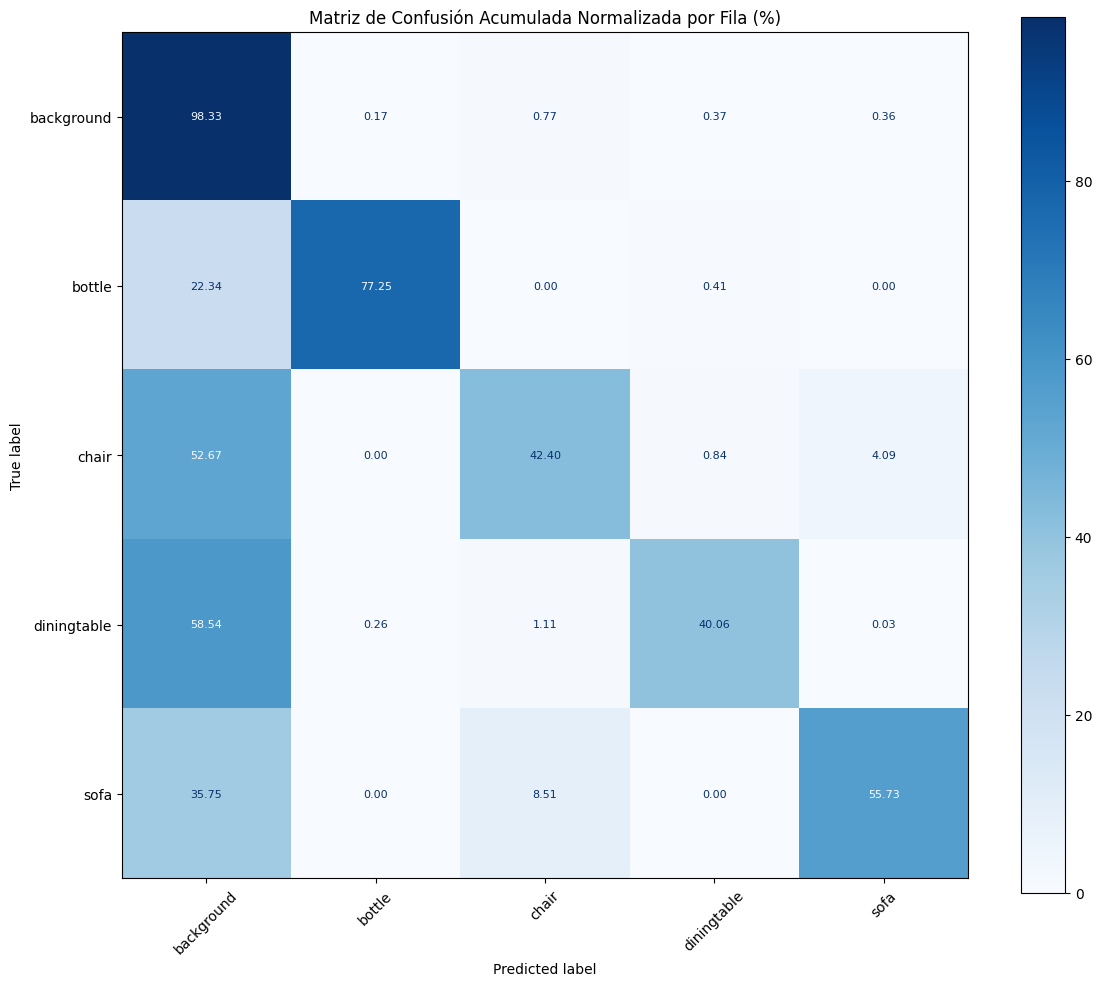

In [69]:
# Inference
weights=torch.load(os.path.join(result_dir,model_name+'_best.pth.tar'))['state_dict']
model = get_deeplabv3(num_classes)
model.to(device)
model.load_state_dict(weights)
model.eval()
cm_total = test_segmentation_model(model, dataloaders, num_classes, class_names, result_dir, True, batchsize_test)

## Parte 3. Experimentos

### 1. Utilidad de las capas *atrous* y el ASPP

En este experimento, para poder observar la capacidad de representación del ASPP con capas *atrous*, se construye una red similar a Deeplab-V2 sobre la arquitectura que tenemos. En Deeplab-V2 las capas *atrous* se encuentran justamente por delante de la función de *loss*, de manera que sus activaciones están __directamente relacionadas__ con la segmentación de salida de la red. En nuestra red sin embargo, las capas *atrous* están __más alejadas__ de la función de *loss* de manera que es __más difícil analizar sus activaciones__. Para convertir nuestra arquitectura en la de Deeplab-V2, se realiza lo siguiente:

- Se elimina el bloque ASPP de Deeplab-V3, que contiene el *avg pooling*.
- Se añade el bloque ASPP de Deeplab-V2, con 4 convoluciones *atrous* de tasa $r=6, 12, 18$ y $24$. A las salidas de cada rama del ASPP se coloca una capa de convolución que convierte cada mapa de características al tamaño del mapa de salida (según el número de clases, en nuestro caso 2, *background* + cúpula óptica).
- Se suman las contribuciones de cada rama para generar la salida y se aplica la función de *loss*.

La siguiente figura muestra los cambios que se realizan para visualizar las activaciones.

<img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/deeplabv3v2.png" width="600pix">

De este modo, se pueden visualizar las salidas marginales de cada rama y ver cómo funcionan las convoluciones *atrous* a partir de sus activaciones.

- Analice las activaciones de cada rama para las imágenes de test. ¿Qué diferencias encuentra y a qué se deben? ¿Cómo contribuyen las convoluciones *atrous* y el ASPP a mejorar la segmentación? ¿Serán útiles si hay muchos objetos en la imagen (segmentación densa)?

In [80]:
class Sum(torch.nn.Module):
    def __init__(self, num_classes):
        super(Sum, self).__init__()
        self.num_classes = num_classes
    def forward(self, x):
        x=x.unsqueeze(1)
        x=x.view(x.size(0),4,self.num_classes,x.size(3),x.size(4))
        x=torch.sum(x,dim=1)
        return x

def get_deeplabv2(num_classes=1):
    model=get_deeplabv3(num_classes=2)
    # Remove the last avg pooling
    model.classifier[0].convs=model.classifier[0].convs[:-1]
    # Change the convolutions from the remaining blocks r=6,12,28 and 24 and adding conv-layers to each branch
    modules = []
    modules.append(torch.nn.Conv2d(2048,256, kernel_size=3,stride=1,padding=6,dilation=6))
    modules.append(model.classifier[0].convs[0][1])
    modules.append(model.classifier[0].convs[0][2])
    modules.append(torch.nn.Conv2d(256, num_classes, kernel_size=1))
    model.classifier[0].convs[0]=torch.nn.Sequential(*modules)
    modules = []
    modules.append(torch.nn.Conv2d(2048,256, kernel_size=3,stride=1,padding=12,dilation=12))
    modules.append(model.classifier[0].convs[1][1])
    modules.append(model.classifier[0].convs[1][2])
    modules.append(torch.nn.Conv2d(256, num_classes, kernel_size=1))
    model.classifier[0].convs[1]=torch.nn.Sequential(*modules)
    modules = []
    modules.append(torch.nn.Conv2d(2048,256, kernel_size=3,stride=1,padding=18,dilation=18))
    modules.append(model.classifier[0].convs[2][1])
    modules.append(model.classifier[0].convs[2][2])
    modules.append(torch.nn.Conv2d(256, num_classes, kernel_size=1))
    model.classifier[0].convs[2]=torch.nn.Sequential(*modules)
    modules = []
    modules.append(torch.nn.Conv2d(2048,256, kernel_size=3,stride=1,padding=24,dilation=24))
    modules.append(model.classifier[0].convs[3][1])
    modules.append(model.classifier[0].convs[3][2])
    modules.append(torch.nn.Conv2d(256, num_classes, kernel_size=1))
    model.classifier[0].convs[3]=torch.nn.Sequential(*modules)
    # Sum the marginal predictions for each branch
    model.classifier[0].project=Sum(num_classes)
    model.classifier=model.classifier[0]
    return model

model_name='deeplabv2'

model = get_deeplabv2(num_classes)
print(model)
model.to(device)

# Training stage
model.train()

# Specify the loss function
criterion = torch.nn.CrossEntropyLoss(reduction='mean')# 3 classes

# Specify the optimizer with a lower learning rate for backbone
params_classifier = [p for p in model.classifier.parameters() if p.requires_grad]

params_backbone = [p for p in model.backbone.parameters() if p.requires_grad]

# Initialize the classifier-conv_layer weights, to adapt to the new paradigm (retinography vs natural images)
torch.manual_seed(manualSeed)
model.classifier.apply(weights_init)

# We apply a different lr to backbone and classifier parts
optimizer = torch.optim.Adam([
{'params': params_backbone},
{'params': params_classifier, 'lr': 1e-4}
], lr=1e-5)

lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                          step_size=step_size,
                                          gamma=0.1)

# Specify the evaluation metrics
metrics = {'jaccard_score': jaccard_score, 'auroc': roc_auc_score}

num_epochs = 16
criterion = torch.nn.CrossEntropyLoss(reduction='mean')# 3 classes
trained_model = train_model(model, criterion, dataloaders, device,
                        optimizer, lr_scheduler, bpath=result_dir, model_name=model_name,
                        metrics=metrics, num_classes=num_classes, num_epochs=num_epochs)

/Users/juan.macias@feverup.com/Desktop/cv/.conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/juan.macias@feverup.com/Desktop/cv/.conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

100%|██████████| 234/234 [01:35<00:00,  2.46it/s]


Train Loss: 0.0029


100%|██████████| 68/68 [00:16<00:00,  4.22it/s]


...

Val Loss: 2.1380
{'epoch': 15, 'Train_loss': 0.14767427742481232, 'Val_loss': 2.1379830837249756, 'Train_jaccard_score': np.float64(0.7358922283771829), 'Train_auroc': np.float64(0.9952432794392696), 'Val_jaccard_score': np.float64(0.4743578209541667), 'Val_auroc': np.float64(0.969461499892624)}
Epoch 16/16
----------


100%|██████████| 234/234 [01:35<00:00,  2.45it/s]


Train Loss: 0.0000


100%|██████████| 68/68 [00:16<00:00,  4.20it/s]


Val Loss: 2.1386
{'epoch': 16, 'Train_loss': 1.1031555914087221e-05, 'Val_loss': 2.138566732406616, 'Train_jaccard_score': np.float64(0.7375123261598069), 'Train_auroc': np.float64(0.9952500775786634), 'Val_jaccard_score': np.float64(0.47433586483239265), 'Val_auroc': np.float64(0.9694591963575542)}
Training complete in 30m 7s
Highest Jaccard: 0.4794


__**IMPORTANTE:__ la función externa `get_activations` proporciona una representación visual de las salidas del ASPP, que almacena en la carpeta `activations` en el directorio de resultados. Sus entradas son:

- __model__: la CNN que evaluar.
- __dataloaders__: el cargador de los datos de test.
- __device__: el dispositivo que utilizar para el entrenamiento (GPU o CPU).
- __result_dir__: el directorio de resultados.
- __batchsize_test__: el tamaño de batch para test, que debe ser 1.

__**IMPORTANTE:__ la función `get_activations` hace uso de los *hook* de Pytorch. Los *hook* de Pytorch son una serie de funciones que permiten modificar los datos de entrada o salida de alguna capa de la red durante la ejecución de la red. Esto permite tener acceso a datos intermedios de la red en tiempo de ejecución, así como realizar un *debug* controlado de la red neuronal. En concreto se usa un *register_forward_hook()*, se ejecuta tras el método *forward* de cualquier capa de la red y tiene acceso a sus entradas y salidas.

/Users/juan.macias@feverup.com/Desktop/cv/.conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/juan.macias@feverup.com/Desktop/cv/.conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 68/68 [00:17<00:00,  3.94it/s]


Jaccard index per class: [0.15254051 0.11553209 0.07315654 0.17959577]


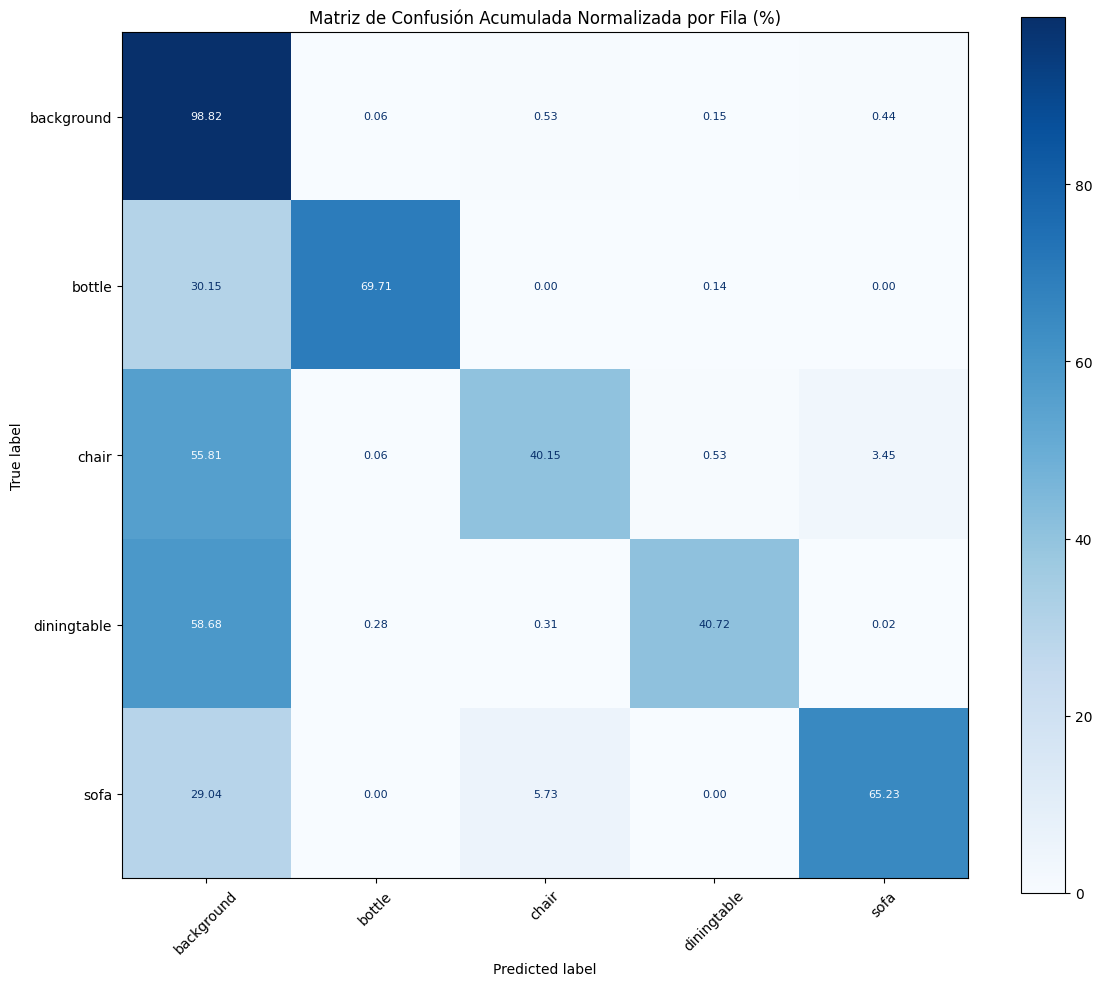

In [82]:
from external import get_activations
# Code to obtain the activations
weights=torch.load(os.path.join(result_dir,model_name+'_best.pth.tar'))['state_dict']
model = get_deeplabv2(num_classes)
model.to(device)
model.load_state_dict(weights)
model.eval()
get_activations(model, dataloaders, device, result_dir, batchsize_test)

# Added to visualize results
cm_total = test_segmentation_model(model, dataloaders, num_classes, class_names, result_dir, True, batchsize_test)

# Analisis de activaciones

![original image](/Users/juan.macias@feverup.com/Desktop/cv/cv-2a-image-segmentation/VA_Pr2A_ImageSegmentation_2025_2026/results/predictions_multiclass/2008_002864.png)
![activation _0](results/activations/2008_002864_0.png)
![activation _1](results/activations/2008_002864_1.png)
![activation _2](results/activations/2008_002864_2.png)
![activation _3](results/activations/2008_002864_3.png)

> ¿Qué diferencias encuentra y a qué se deben? ¿Cómo contribuyen las convoluciones *atrous* y el ASPP a mejorar la segmentación? ¿Serán útiles si hay muchos objetos en la imagen (segmentación densa)?

De izquierda a derecha, vemos las activaciones de cada una de las 4 ramas ASPP, cuyas convoluciones `atrous` varían en el valor del rate (6, 12, 18 y 24 respectivamente). Estamos visualizando 1 de las 5 dimensiones del output: la primera corresponde con la clase "botella", por lo que podemos ver mayores valores (más claros) donde el modelo infiere que hay una botella.

Las 4 imagenes tienen localidad distinta: las convoluciones menos dilatadas crean representaciones mas especificas, más locales, mientras que las más dilatadas aportan un contexto global y más suave.

Otra observación es que el modelo "ve botellas" en las botellas de la imagen, si no también en las dos personas sentadas en la mesa. Se pueden considerar falsos positivos intermedios, unos errores que la capa siguiente tiene que aprender a reconocer.

> Por qué se parecen todas mucho?
Tras investigar un poco, la razón puede ser que no existe una rama de average pooling. Esa rama, que reduce el vector entero a un unico punto. Eso significa que no tiene localidad, por lo que codifica información global, lo cual permite a la capa siguiente interpretar la información local del resto de rama en un sentido o en otro. Sin la rama de avg pool (get_deeplabv2), las 5 ramas son cualitativamente homogéneas — todas locales, todas con gradiente similar — y el modelo tiende al equilibrio: puede estar aprendiendo a distribuir la misma información entre ellas porque no hay incentivo para especializarse

### 2. Funciones de pérdida

En este apartado se van a describir situaciones  con la función de pérdida de la red para posteriores experimentos. A la hora de entrenar una red de segmentación, hay que tener en cuenta dos cosas principalmente: el desbalanceo de las clases; si existe, y el uso de estrategias de regularización de la función de pérdida pixelar. Ambas se definen a continuación.

#### Desbalanceo de las clases

El desbalanceo de las clases ocurre cuando algunas de las clases en la salida dominan sobre el resto (es decir, la proporción de píxeles pertenecientes a las distintas clases es muy desigual). Esto puede provocar que la red tienda a dar demasiada importancia a las clases más representadas a costa de reducir la importancia (o incluso hacer desaparecer) clases poco representadas. Esto se puede comprender mejor si se analiza a nivel de píxel: __la función de pérdida estándar aplica la misma importancia a todos los píxeles de la salida, independientemente de su clase, es decir, la red se va a centrar en clasificar cada uno de ellos correctamente, sea cual sea su clase. Sin embargo, si existe desbalanceo para las clases, un error en una clase poco representada (1 error sobre 10 píxeles, por ejemplo) será más perjudicial para el rendimiento del sistema que un error en una clase muy representada (1/1000)__. Si se une esto a que la red puede aprender mejor la clase muy representada porque tiene un mayor número de ejemplos de la misma, el resultado de la segmentación puede ser poco preciso

Como estrategia para mitigar esto se propone una muy sencilla: se basa en aplicar una serie de pesos a las clases en la función de pérdida según su probabilidad de aparición en el conjunto de entrenamiento. Esto provoca que la red no ponga el mismo énfasis en clasificar cada píxel, sino que un error en un píxel de una clase poco representada dará un valor de la función de pérdida mayor que en una clase muy representada, de manera que la red pone más énfasis en resolver los errores sobre la clase más "difícil". Sin embargo, esta estrategia es sensible a los pesos que se apliquen a las clases.

#### Estrategias de regularización

Por otra parte, la función de pérdida pixelar no tiene en cuenta ninguna dependencia entre los píxeles de la imagen (es decir, a la función contribuyen de igual manera todos los píxeles de la imagen; y entre ellos no se impone ninguna relación). Sin embargo, en el caso de la segmentación de imágenes existe una fuerte dependencia entre los píxeles:

- A nivel local, píxeles adyacentes a uno clasificado como perteneciente a la clase 'X' por ejemplo, tienen más probabilidad de ser de la clase 'X' que de la clase 'Y' en imágenes naturales (los objetos son continuos hasta que se llega a sus bordes). Existen estrategias sobre la función de pérdida que pueden reforzar la coherencia local en las segmentaciones (véase *'pairwise penalties'* en [6]).
- A nivel de imagen, existirán imágenes que la red segmente correctamente y otras en las que el desempeño sea menor. Existen funciones de pérdida que modelan esto (hacen que la red se centre en las imágenes más complejas) y combinadas con la función pixelar pueden resultar de ayuda, como la Dice Loss, en [8].
- En objetos no uniformes (con regiones con aspectos muy diferentes), pueden existir ciertos tipos de regiones que la red segmente muy bien y otras que sean complejas. Una función de pérdida que dé mayor importancia a los píxeles mal clasificados que a los correctamente clasificados puede ser útil. De este modo la red se centrará en clasificar correctamente dichos píxeles (lo que frecuentemente no afecta a los píxeles ya correctamente clasificados, que son más sencillos) y los resultados mejorarán. Esto equivale a hacer un procedimiento de *Hard Negative Mining* sobre los píxeles (es decir, centrarse en aquellos que resultan más difíciles para la red). La función Focal Loss [7] puede ser un buen ejemplo.